# **Asignatura**: Aprendizaje Automático

**Práctica 3**: Introducción a Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 23 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: LAURA SALAS LÓPEZ



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Aprendizaje Supervisado (5 puntos)**

## 1.1 Contexto: Análisis de Sentimientos en Reseñas de Cine

En este ejercicio abordaremos un problema clásico de **Procesamiento de Lenguaje Natural (NLP)** utilizando redes neuronales densas (Perceptrón Multicapa).

El objetivo es clasificar reseñas de películas como **Positivas (1)** o **Negativas (0)** basándose en el texto de la crítica.

**Dataset:** IMDB Movie Reviews. Contiene 50.000 reseñas altamente polares. Keras proporciona este dataset preprocesado, donde las palabras ya han sido convertidas a secuencias de enteros (índices en un diccionario).

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Carga del dataset IMDB limitado a las 10,000 palabras más frecuentes
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)

print(f"Entrenamiento: {len(train_data)} reseñas")
print(f"Test: {len(test_data)} reseñas")

# Ejemplo de una reseña (enteros)
print("Ejemplo de reseña (indices):", train_data[0])

Entrenamiento: 25000 reseñas
Test: 25000 reseñas
Ejemplo de reseña (indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5

## 1.2 Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesado de datos (Vectorización):**
    * Las listas de enteros tienen longitudes variables, lo cual no es admisible para una red densa estándar. Debe transformar las listas en tensores de tamaño fijo.
    * **Tarea:** Implemente una función para realizar **One-hot Encoding** (o Multi-hot) que convierta cada reseña en un vector de dimensión 10,000 (donde 1 indica la presencia de la palabra y 0 su ausencia).
    * Vectorice tanto los datos de train como los de test.

2.  **Construcción del Modelo:**
    * Diseñe una red neuronal secuencial (`tf.keras.Sequential`).
    * Use 2 o 3 capas densas (`Dense`).
    * Use funciones de activación `relu` para las capas ocultas.
    * **Importante:** La capa de salida debe tener 1 sola neurona con activación `sigmoid` (para clasificación binaria).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Función de pérdida: `binary_crossentropy`.
    * Métrica: `accuracy`.
    * Separe una parte de los datos de entrenamiento para validación.
    * Entrene durante 20 épocas.

4.  **Evaluación:**
    * Muestre la gráfica la evolución de la pérdida (`loss`) y la precisión (`accuracy`) tanto en entrenamiento como en validación.
    * Evalúe el modelo final sobre el conjunto de test.

### 1. Preprocesado de datos

Para vectorizar los datos, he implementado la función `vectorize_sequence`. Dicha función crea una matriz de ceros y pone a 1 las posiciones correspondientes al índice de las palabras incluidas en cada reseña. Esto estandariza la longitud de todas las muestras a 10.000 dimensiones, requisito necesario para la capa de entrada de nuestra red densa.

Además, he transformado tanto los datos como las etiquetas en tensores de TensorFlow de tipo `float32`. Esto evitará castings que puedan ralentizar el entrenamiento.

In [2]:
# Función para vectorizar secuencia (One-hot encoding)
def vectorize_sequence(sequence, dimension=10000):
    results = np.zeros((len(sequence), dimension))
    for i, seq in enumerate(sequence):
        # Marcamos a 1 los índices correspondientes
        results[i, seq] = 1.
    return results

# Vectorizamos los datos de entrenamiento y test
x_train_vect = vectorize_sequence(train_data)
x_test_vect = vectorize_sequence(test_data)

# Pasamos a tensores
tXtrain = tf.convert_to_tensor(x_train_vect, dtype=tf.float32)
tXtest = tf.convert_to_tensor(x_test_vect, dtype=tf.float32)

tYtrain = tf.convert_to_tensor(train_labels, dtype=tf.float32)
tYtest = tf.convert_to_tensor(test_labels, dtype=tf.float32)

print('Muestras de training: ', tXtrain.shape, tYtrain.shape)
print('Muestras de test: ', tXtest.shape, tYtest.shape)

Muestras de training:  (25000, 10000) (25000,)
Muestras de test:  (25000, 10000) (25000,)


### 2. Construcción del modelo

Para el modelo, he elegido una arquitectura de dos capas ocultas `Dense` con función de activación `relu`, una arquitectura estándar para extraer patrones no lineales en NLP. La capa de salida consta de una única neurona con activación `sigmoid`, ya que se trata de un problema de clasificación binaria (crítica Positiva vs Negativa) y necesitamos que devuelva una probabilidad en el rango [0, 1].

Para determinar empíricamente la arquitectura óptima y los hiperparámetros ideales, he implementado un bucle para probar distintas combinaciones (*Grid Search*). En lugar de fijar valores arbitrarios, evaluo el rendimiento del modelo frente al conjunto de validación iterando sobre distinto número de neuronas (8, 16, 32), tasas de aprendizaje (0.001, 0.0001) y tamaños de lote (256, 512). La selección del modelo final se basará en la métrica *Validation Accuracy* para garantizar la máxima capacidad de generalización.

In [3]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy

# Hiperparámetros a probar
neuronas_list = [8, 16, 32]
learning_rates = [0.001, 0.0001]
batch_sizes = [256, 512]
epochs_busqueda = 8

resultados = []

# Grid Search manual
for neuronas in neuronas_list:
    for lr in learning_rates:
        for bs in batch_sizes:
            print(f"Probando -> Neuronas: {neuronas:2d} | LR: {lr:.4f} | Batch: {bs:3d}...", end=" ")

            # Construir modelo
            model_test = Sequential()
            model_test.add(Input(shape=(tXtrain.shape[1],)))
            model_test.add(Dense(neuronas, activation='relu'))
            model_test.add(Dense(neuronas, activation='relu'))
            model_test.add(Dense(1, activation='sigmoid'))

            # Compilar
            model_test.compile(optimizer=Adam(learning_rate=lr),
                               loss=binary_crossentropy,
                               metrics=['accuracy'])

            # Entrenar
            history_test = model_test.fit(
                tXtrain, tYtrain,
                epochs=epochs_busqueda,
                batch_size=bs,
                validation_split=0.2,
                verbose=0
            )

            # Obtener las métricas
            val_acc = history_test.history['val_accuracy'][-1]
            val_loss = history_test.history['val_loss'][-1]

            print(f"Terminado. Val_Acc: {val_acc:.4f} | Val_Loss: {val_loss:.4f}")

            # Guardar resultados
            resultados.append({
                'neuronas': neuronas,
                'lr': lr,
                'batch_size': bs,
                'val_acc': val_acc,
                'val_loss': val_loss
            })

# Resultados finales
# Encontrar el diccionario con el mayor 'val_acc'
mejor_modelo = max(resultados, key=lambda x: x['val_acc'])

print("\n===============================")
print("LA MEJOR CONFIGURACIÓN ES:")
print("================================")
print(f" > Neuronas en capas ocultas: {mejor_modelo['neuronas']}")
print(f" > Tasa de aprendizaje (LR):  {mejor_modelo['lr']}")
print(f" > Tamaño de lote (Batch):    {mejor_modelo['batch_size']}")
print(f" > Exactitud de validación:   {mejor_modelo['val_acc']:.4f}")
print("================================")

Probando -> Neuronas:  8 | LR: 0.0010 | Batch: 256... Terminado. Val_Acc: 0.8822 | Val_Loss: 0.4005
Probando -> Neuronas:  8 | LR: 0.0010 | Batch: 512... Terminado. Val_Acc: 0.8882 | Val_Loss: 0.2980
Probando -> Neuronas:  8 | LR: 0.0001 | Batch: 256... Terminado. Val_Acc: 0.8846 | Val_Loss: 0.3380
Probando -> Neuronas:  8 | LR: 0.0001 | Batch: 512... Terminado. Val_Acc: 0.8624 | Val_Loss: 0.4656
Probando -> Neuronas: 16 | LR: 0.0010 | Batch: 256... Terminado. Val_Acc: 0.8730 | Val_Loss: 0.5441
Probando -> Neuronas: 16 | LR: 0.0010 | Batch: 512... Terminado. Val_Acc: 0.8760 | Val_Loss: 0.3820
Probando -> Neuronas: 16 | LR: 0.0001 | Batch: 256... Terminado. Val_Acc: 0.8880 | Val_Loss: 0.2992
Probando -> Neuronas: 16 | LR: 0.0001 | Batch: 512... Terminado. Val_Acc: 0.8836 | Val_Loss: 0.3550
Probando -> Neuronas: 32 | LR: 0.0010 | Batch: 256... Terminado. Val_Acc: 0.8656 | Val_Loss: 0.6285
Probando -> Neuronas: 32 | LR: 0.0010 | Batch: 512... Terminado. Val_Acc: 0.8716 | Val_Loss: 0.5296


Tras ejecutar la búsqueda de hiperparámetros, la configuración óptima obtenida es: **32 neuronas, Tasa de Aprendizaje de 0.0001 y tamaño de Batch de 256**, alcanzando una exactitud de validación del 89% y la pérdida más baja (0.27).

El análisis de estos resultados nos dice lo siguiente:

- El impacto del Learning Rate: Cuando la arquitectura de 32 neuronas se entrenó con un LR alto (0.001), el modelo sufrió mucho overfitting (Val_Loss = 0.66). Sin embargo, al reducir el LR a 0.0001, la actualización de los pesos se volvió lo suficientemente conservadora como para impedir la memorización del ruido.

- Esta combinación ganadora permite que el modelo aproveche su alta capacidad de representación (32 neuronas) para aprender patrones complejos, mientras que el LR bajo actúa como un regularizador durante las 8 épocas. El tamaño de batch más pequeño (256) evita caer en mínimos locales.

Por tanto, adopto estos hiperparámetros para el modelo final, demostrando que una mayor capacidad neuronal (32) requiere tasas de aprendizaje más conservadoras para mantener la capacidad de generalización en las etapas iniciales del entrenamiento.

In [4]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

# Modelo secuencial
model_1 = Sequential()

model_1.add(Input(shape=(tXtrain.shape[1],)))

# Primera capa oculta + relu
model_1.add(Dense(32, activation='relu'))

# Segunda capa oculta + relu
model_1.add(Dense(32, activation='relu'))

# Capa densa de salida con activación sigmoid
model_1.add(Dense(1, activation='sigmoid'))

model_1.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,121 (1.22 MB)

 Trainable params: 321,121 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Compilación y entrenamiento

Ahora pasamos a la compilación y el entrenamiento del modelo. Señalar lo siguiente:

- **Función de Pérdida:** Se nos pide utilizar `binary_crossentropy`. Esta es la función matemáticamente correcta cuando la capa de salida consta de una única neurona con activación sigmoide, ya que penaliza fuertemente las predicciones divergentes y maximiza la verosimilitud de las probabilidades predichas frente a las etiquetas reales (0 o 1).

- **Optimizador:** He optado por `Adam` porque, a diferencia del SGD básico, tiene en cuenta los momentos de las actualizaciones anteriores. Esto le permite ir adaptando la tasa de aprendizaje sobre la marcha, logrando que la red converja más rápido y no se quede atascada en mínimos locales.

- **Hiperparámetros de Entrenamiento:**

  - Se ha fijado un `batch_size` de 256. Tras evaluar distintas configuraciones, se determinó que este tamaño de lote ofrece el equilibrio perfecto. Al ser más pequeño que el estándar de 512, introduce un nivel adecuado de ruido en la estimación del gradiente. Esta aleatoriedad actúa como un regularizador implícito que ayuda al modelo a escapar de mínimos locales y previene la memorización temprana de los datos.

  - Se ha utilizado un `validation_split` del 0.2 (20%). Es necesario reservar una porción de los datos para validar el modelo en cada época y controlar el overfitting.

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy

# Hiperparámetros
lmbda = 0.0001      # Tasa de aprendizaje
epochs = 20         # Número de iteraciones sobre todo el dataset
bs = 256            # Tamaño del batch para procesar en paralelo
val_rate = 0.2      # 20% de los datos de entrenamiento se usarán para validación

# Compilación
optimizer = Adam(learning_rate=lmbda)
loss_function = binary_crossentropy
metrics = ['accuracy']

model_1.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

# Entrenamiento
history = model_1.fit(
    tXtrain,
    tYtrain,
    epochs=epochs,
    batch_size=bs,
    validation_split=val_rate,
    verbose=1
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6568 - loss: 0.6658 - val_accuracy: 0.7756 - val_loss: 0.6124
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8307 - loss: 0.5454 - val_accuracy: 0.8506 - val_loss: 0.4819
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8767 - loss: 0.4218 - val_accuracy: 0.8746 - val_loss: 0.3937
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8968 - loss: 0.3423 - val_accuracy: 0.8822 - val_loss: 0.3440
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9091 - loss: 0.2909 - val_accuracy: 0.8856 - val_loss: 0.3135
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9190 - loss: 0.2550 - val_accuracy: 0.8886 - val_loss: 0.2926
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9272 - loss: 0.2255 - val_accuracy: 0.8936 - val_loss: 0.2807
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9337 - loss: 0.2038 - val_accuracy: 0.8942 - va

### 4. Evaluación

Para evaluar la capacidad de generalización del modelo, he empleado el método `evaluate` sobre los tensores de validación/test, extrayendo tanto el valor de la función de pérdida como la métrica objetivo (Accuracy).

CONJUNTO DE ENTRENAMIENTO
	Loss Value: 0.1246
	accuracy: 0.9631

CONJUNTO DE TEST
	Loss Value: 0.3393
	accuracy: 0.8766


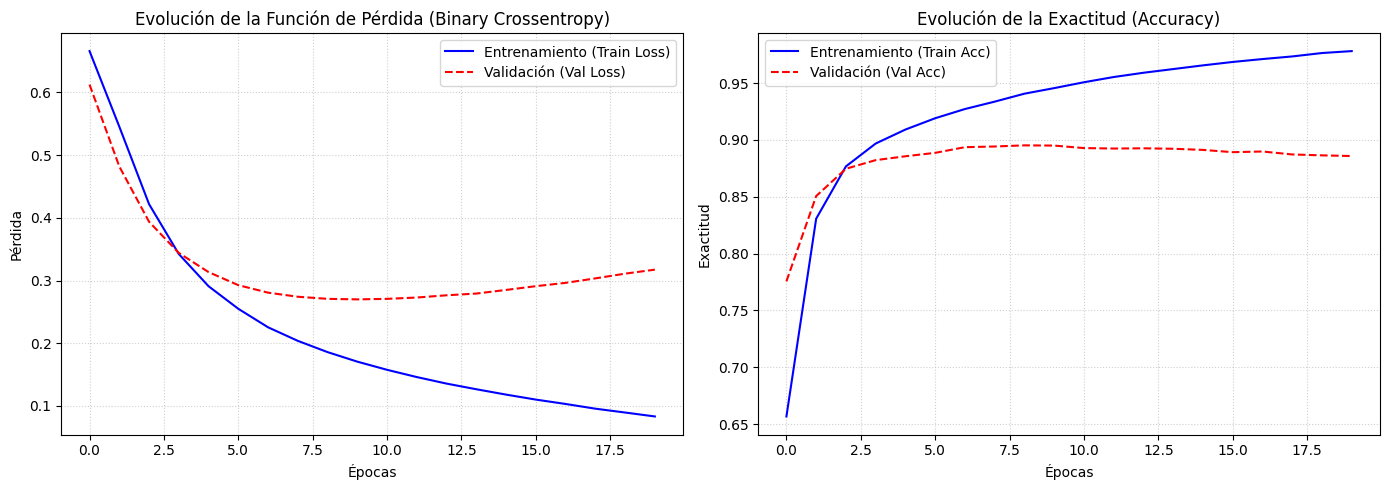

In [6]:
ScoresTrain = model_1.evaluate(tXtrain, tYtrain, verbose=0)
ScoresTest  = model_1.evaluate(tXtest, tYtest, verbose=0)

print('CONJUNTO DE ENTRENAMIENTO')
print('\tLoss Value: {:.4f}'.format(ScoresTrain[0]))
for i in range(len(metrics)):
    print('\t{}: {:.4f}'.format(metrics[i], ScoresTrain[i+1]))

print('\nCONJUNTO DE TEST')
print('\tLoss Value: {:.4f}'.format(ScoresTest[0]))
for i in range(len(metrics)):
    print('\t{}: {:.4f}'.format(metrics[i], ScoresTest[i+1]))


plt.figure(figsize=(14, 5))

# Gráfica de la Función de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Train Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Validación (Val Loss)', color='red', linestyle='--')
plt.title('Evolución de la Función de Pérdida (Binary Crossentropy)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Gráfica de la Exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento (Train Acc)', color='blue')
plt.plot(history.history['val_accuracy'], label='Validación (Val Acc)', color='red', linestyle='--')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Análisis Cuantitativo**

Al comparar el rendimiento, observamos que el modelo obtiene una accuracy de 96% en el conjunto de entrenamiento y un 87% en el conjunto de test. Esta diferencia es un indicador de que el modelo ha sufrido un grado de overfitting.

**Análisis Visual**

En la gráfica de Pérdida, se observa cómo la curva de entrenamiento decrece hacia cero, lo que indica que la red está memorizando los datos. Sin embargo, la curva de validación decrece solo hasta la época 5. A partir de ese punto de inflexión, la pérdida de validación comienza a aumentar progresivamente.

En la gráfica de Accuracy, la curva de validación se estanca alrededor de la misma época, dejando de mejorar a pesar de que la exactitud de entrenamiento sigue subiendo hasta rozar el 100%.


Como conclusión, el modelo presenta una buena capacidad de aprendizaje, pero sufre un overfitting temprano. Las gráficas nos indican que, a partir de la época 5, la red comienza a memorizar el ruido de los datos de entrenamiento en lugar de generalizar.

---

# **Ejercicio 2: Aprendizaje No Supervisado (5 puntos)**

## 2.1 Contexto: Eliminación de Ruido en Imágenes (Denoising Autoencoder)

En este ejercicio utilizaremos una arquitectura de tipo **Autoencoder Convolucional** para una tarea de aprendizaje no supervisado: la restauración de imágenes.

El objetivo no es clasificar qué número hay en la imagen, sino aprender a **limpiar** una imagen que ha sido corrompida por ruido aleatorio.

**Dataset:** MNIST (Dígitos manuscritos). Nosotros introduciremos el ruido artificialmente.

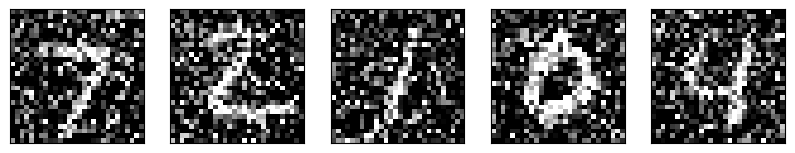

In [7]:
# Carga y normalización de MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalización [0, 1] y reshape a (28, 28, 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Función para añadir ruido aleatorio
def add_noise(images, noise_factor=0.5):
    noisy_imgs = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy_imgs, 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Visualización del ruido
n = 5
plt.figure(figsize=(10, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 2.2 Tareas a realizar

1.  **Construcción del Autoencoder:**
    * Debe construir un modelo que tenga dos partes: **Encoder** y **Decoder**.
    * **Encoder:** Use capas `Conv2D` y `MaxPooling2D` para comprimir la imagen.
    * **Decoder:** Use capas `Conv2D` y `UpSampling2D` (o `Conv2DTranspose`) para reconstruir la imagen al tamaño original (28x28).
    * La capa de salida debe tener 1 filtro y activación `sigmoid` (para que los píxeles estén entre 0 y 1).

2.  **Entrenamiento:**
    * **Entrada (X):** Imágenes con ruido (`x_train_noisy`).
    * **Objetivo (Y):** Imágenes originales limpias (`x_train`).
    * Pérdida: `binary_crossentropy` (funciona bien píxel a píxel) o `mse`.
    * Entrene por al menos 10 épocas.

3.  **Resultados:**
    * Utilice el modelo entrenado para limpiar las imágenes de test (`x_test_noisy`).
    * Visualice una comparativa: **Original** | **Ruidosa** | **Reconstruida** para al menos 5 ejemplos.

### 1. Construcción del Autoencoder

Empiezo convirtiendo los datos a tensores de TensorFlow.

In [8]:
tXtrain_noisy = tf.convert_to_tensor(x_train_noisy, dtype=tf.float32)
tXtrain_clean = tf.convert_to_tensor(x_train, dtype=tf.float32)
tXtest_noisy  = tf.convert_to_tensor(x_test_noisy, dtype=tf.float32)
tXtest_clean  = tf.convert_to_tensor(x_test, dtype=tf.float32)

print('Shape del input ruidoso (Train):', tXtrain_noisy.shape)
print('Shape del objetivo limpio (Train):', tXtrain_clean.shape)

Shape del input ruidoso (Train): (60000, 28, 28, 1)
Shape del objetivo limpio (Train): (60000, 28, 28, 1)


Ya podemos pasar a implementar el Autoencoder.
- **Encoder:** Utiliza capas `Conv2D` para detectar patrones espaciales y `MaxPooling2D` para reducir la resolución, obligando a la red a descartar el ruido y quedarse solo con la estructura esencial del dígito.
  - Número de filtros: Empezamos con 32 para buscar patrones simples (bordes, líneas). En la segunda etapa, pasamos a 16 para comprimir la información. Así obligamos a descartar el ruido y quedarse solo con las características principales de la imagen.
  - Kernel Size (3, 3): Suficientemente pequeño para captar detalles locales y suficientemente grande para entender el contexto de los píxeles vecinos.
  - `relu`: Introduce no linealidad, permitiendo que la red aprenda estructuras complejas.  

- **Decoder:** Emplea capas de `UpSampling2D` para recuperar el tamaño original de 28x28. La capa final utiliza una activación `sigmoid` para asegurar que los valores de salida representen correctamente la intensidad de los píxeles en el rango normalizado [0, 1].
  - Número de filtros: Al contrario que en en el Encoder, ahora empezamos con 16 y después 32 para ir expandiendo la información de nuevo.

El uso de `padding='same'` es crucial para mantener las dimensiones controladas durante las convoluciones.

In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

autoencoder = Sequential()

# ENCODER
# Capa de entrada: Imágenes de 28x28 con 1 canal
autoencoder.add(Input(shape=(28, 28, 1)))

# Primera capa convolucional
autoencoder.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D((2, 2), padding='same'))

# Segunda capa convolucional
autoencoder.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D((2, 2), padding='same'))

# DECODER
# Reconstrucción de la resolución original
autoencoder.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D((2, 2)))

autoencoder.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D((2, 2)))

# Capa de salida: 1 filtro y activación sigmoid
autoencoder.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

autoencoder.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Entrenamiento

- **Función de pérdida:** He optado por `binary_crossentropy` porque trata el valor de cada píxel como una probabilidad de intensidad, resultando en bordes y formas más nítidas que con MSE.

- **Entrenamiento:** El modelo aprende de forma no supervisada al intentar minimizar la diferencia entre su salida y la imagen original sin ruido. Se ha configurado un `batch_size` de 128 para permitir actualizaciones de pesos frecuentes y dinámicas. Además, entrenamos por 15 épocas.

In [10]:
# Hiperparámetros
epochs_ae = 15
bs_ae = 128

# Compilación
autoencoder.compile(optimizer=Adam(learning_rate=0.001),
                    loss='binary_crossentropy')

# Entrenamiento
history_ae = autoencoder.fit(
    tXtrain_noisy,  # X
    tXtrain_clean,  # Y
    epochs=epochs_ae,
    batch_size=bs_ae,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.1956 - val_loss: 0.1274
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1210 - val_loss: 0.1186
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1153 - val_loss: 0.1141
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1120 - val_loss: 0.1117
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1098 - val_loss: 0.1097
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1081 - val_loss: 0.1081
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1067 - val_loss: 0.1069
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1056 - val_loss: 0.1059
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1047 - val_loss: 0.1052
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1039 - val_loss: 0.1047
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1032 - val_loss: 0.1037
Epoch 12/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

### 3. Resultados

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


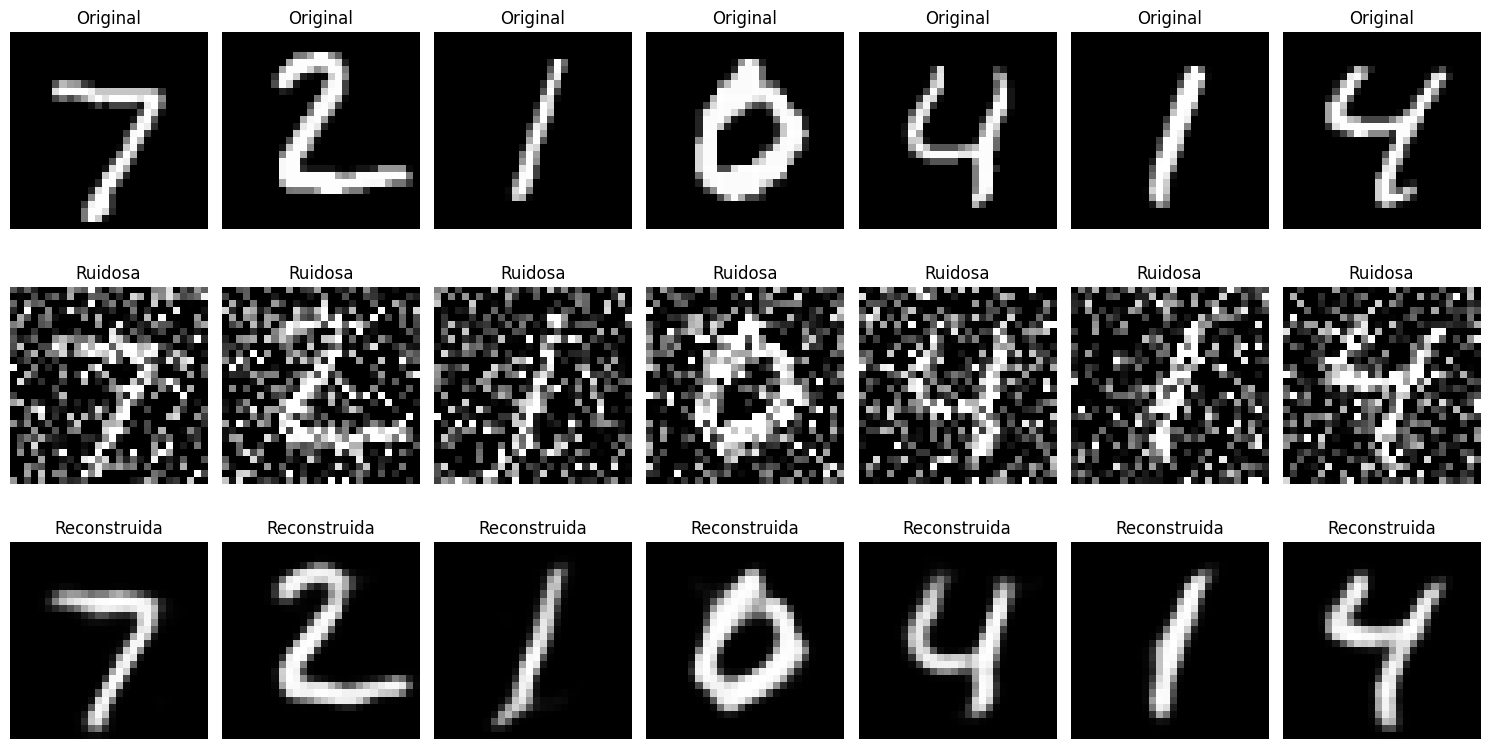

In [11]:
# Limpieza de las imágenes de test
decoded_imgs = autoencoder.predict(tXtest_noisy)

# Visualización de resultados
n = 7  # Número de ejemplos a mostrar
plt.figure(figsize=(15, 8))

for i in range(n):
    # Imagen Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(tXtest_clean[i]), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Imagen Ruidosa
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(tXtest_noisy[i]), cmap='gray')
    plt.title("Ruidosa")
    plt.axis('off')

    # Imagen Reconstruida
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Reconstruida")
    plt.axis('off')

plt.tight_layout()
plt.show()

Tras visualizar la comparativa entre la imagen original, la ruidosa y la reconstruida, se observa una notable capacidad de filtrado. El autoencoder logra eliminar la mayor parte del ruido, recuperando la morfología del dígito original. Si bien puede aparecer una ligera borrosidad, el resultado demuestra que la red ha aprendido una representación interna de los datos lo suficientemente robusta como para separar la señal del ruido.

---

# **Conclusiones Generales**

Añada una celda de texto final comentando las diferencias fundamentales que ha observado en la forma de entrenar un modelo supervisado (donde le damos una etiqueta de clase) frente al no supervisado (donde la propia imagen limpia actúa como supervisor).

Tras realizar esta práctica, destaco las siguientes diferencias fundamentales entre Aprendizaje Supervisado y No Supervisado:

- **Objetivo:** En el modelo supervisado del Ejercicio 1, la red aprende a mapear una entrada (texto) hacia una etiqueta predefinida por un humano (1 o 0, Positivo o Negativo). Por el contrario, en el modelo no supervisado (Autoencoder) del Ejercicio 2, no existen etiquetas de clase externas. La red utiliza la propia estructura interna de los datos limpios como el "supervisor" u objetivo a replicar (Y = X_limpia), aprendiendo a ignorar las anomalías (ruido).

- **Arquitectura:** El modelo supervisado terminó en un cuello de botella de 1 sola neurona con una salida predictiva, obligando a la red a condensar toda la información en un solo valor. El Autoencoder, en cambio, comprime la información, pero su capa final debe proyectar esa información de vuelta a la dimensionalidad original (una imagen de 28x28x1).

- **Función de pérdida:** Aunque en ambos casos aplicamos `binary_crossentropy`, su interpretación es diferente. En el supervisado, penaliza el error de la certeza sobre la clase. En el autoencoder, la entropía cruzada se aplica de manera iterativa píxel a píxel, midiendo el error en la intensidad de la reconstrucción espacial de cada componente de la imagen.

- Mientras que el primer enfoque es ideal para la toma de decisiones, el segundo es fundamental para la extracción de características, la compresión y la limpieza de datos, demostrando la versatilidad de las redes neuronales según el diseño de su arquitectura y su función de coste.